# 05 · שיוך נתונים (Data Association)
**מלווה את ההרצאה:** *Data Association* — Florian Meyer, FUSION Boot Camp 2026.

> ⚠️ שקופיות הרצאה זו **אינן** כלולות ב-PDF. המחברת מבוססת על הספרות הקנונית 
> (Bar-Shalom, Blackman & Popoli) ועל ההקשר שמספק Blasch במבוא.

במחברת 03 ראינו שמסנן קלמן מניח **שיוך מדידה-למסלול מושלם**. במציאות יש מספר מטרות, 
מדידות שווא (clutter), והחמצות (missed detections). שיוך נתונים עונה על השאלה: 
**איזו מדידה שייכת לאיזה מסלול?**

## א. שערוּר (Gating) ומרחק מהלנוביס
לפני שיוך, מסננים מדידות שרחוקות מדי מהחיזוי. ה'שער' (gate) מוגדר ע"י מרחק מהלנוביס בריבוע:
$$d^2 = (z-\hat z)^T S^{-1} (z-\hat z) \le \gamma$$
כאשר $S=HPH^T+R$ היא שונות החדשה (innovation). $d^2$ מתפלג $\chi^2$ עם דרגות חופש כמספר ממדי המדידה.

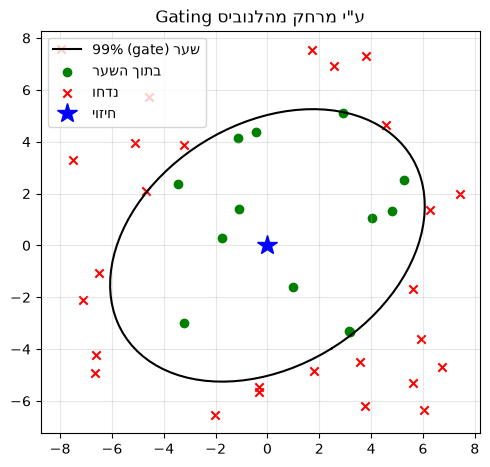

13 מתוך 40 מדידות נכנסו לשער


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
rng = np.random.default_rng(3)

def maha2(z, zhat, S):
    d = (z - zhat).reshape(-1,1)
    return float((d.T @ np.linalg.inv(S) @ d).item())

# חיזוי מטרה במישור עם שונות innovation S; שער chi2 עם 2 dof, 99% -> 9.21
zhat = np.array([0.,0.]); S = np.array([[4.,1.],[1.,3.]]); gamma = 9.21
cands = rng.uniform(-8,8,size=(40,2))
ingate = np.array([maha2(z,zhat,S) <= gamma for z in cands])
th=np.linspace(0,2*np.pi,100); v,Q=np.linalg.eigh(S)
ell=(Q@np.diag(np.sqrt(gamma*v))@np.array([np.cos(th),np.sin(th)]))
plt.figure(figsize=(5,5))
plt.plot(ell[0],ell[1],'k',label='שער (gate) 99%')
plt.scatter(*cands[ingate].T,c='g',label='בתוך השער')
plt.scatter(*cands[~ingate].T,c='r',marker='x',label='נדחו')
plt.plot(*zhat,'b*',ms=15,label='חיזוי'); plt.gca().set_aspect('equal')
plt.legend(); plt.grid(alpha=.3); plt.title('Gating ע"י מרחק מהלנוביס'); plt.tight_layout(); plt.show()
print(f'{ingate.sum()} מתוך {len(cands)} מדידות נכנסו לשער')

## ב. שיוך 'השכן הקרוב הגלובלי' (GNN — Global Nearest Neighbor)
כאשר יש כמה מטרות וכמה מדידות, GNN פותר **בעיית שיבוץ (assignment)**: למצוא את ההתאמה 
חד-חד-ערכית בין מסלולים למדידות שממזערת את עלות השיוך הכוללת (סכום מרחקי מהלנוביס):
$$\min_{\text{שיבוץ}} \sum_{(i,j)} d^2_{ij}$$
פתרון אופטימלי: אלגוריתם הונגרי / auction. כאן נדגים בכוח גס (brute force) עבור מספר קטן של מטרות.

In [2]:
def gnn_assign(cost):
    """שיבוץ אופטימלי (מינימום עלות) בכוח גס — למטריצות קטנות."""
    n,m = cost.shape; best=None; best_c=np.inf
    rows=range(n)
    for perm in permutations(range(m), n):
        c=sum(cost[i,perm[i]] for i in rows)
        if c<best_c: best_c=c; best=perm
    return list(zip(rows,best)), best_c

# 3 מסלולים (חיזויים) ו-3 מדידות
tracks = np.array([[0.,0.],[10.,0.],[5.,8.]])
meas   = np.array([[0.5,0.4],[9.4,0.7],[5.3,7.6]])
Sg = np.eye(2)*1.0
cost = np.array([[maha2(m,t,Sg) for m in meas] for t in tracks])
pairs, total = gnn_assign(cost)
print('עלויות (שורה=מסלול, עמודה=מדידה):'); print(np.round(cost,1))
print('שיבוץ GNN:', [(f'מסלול{i}',f'מדידה{j}') for i,j in pairs], f'  עלות={total:.2f}')

עלויות (שורה=מסלול, עמודה=מדידה):
[[ 0.4 88.9 85.8]
 [90.4  0.8 79.8]
 [78.  72.6  0.3]]
שיבוץ GNN: [('מסלול0', 'מדידה0'), ('מסלול1', 'מדידה1'), ('מסלול2', 'מדידה2')]   עלות=1.51


## ג. PDA — Probabilistic Data Association (מטרה יחידה ב-clutter)
במקום לבחור מדידה אחת, **PDA משקלל את כל המדידות בשער** לפי הסתברות השיוך שלהן. 
עבור מדידות $z_i$ בשער, הסתברות שמדידה $i$ היא הנכונה:
$$\beta_i = \frac{\mathcal{L}_i}{1-P_DP_G+\sum_k \mathcal{L}_k}, \quad \mathcal{L}_i = \frac{P_D}{\lambda}\,\mathcal{N}(z_i;\hat z,S)$$
ו-$\beta_0$ (אף מדידה אינה נכונה). העדכון משתמש ב**חדשה משוקללת** $\bar y=\sum_i\beta_i y_i$, 
עם תוספת לשונות ('spread of innovations') שמבטאת את אי-ודאות השיוך.

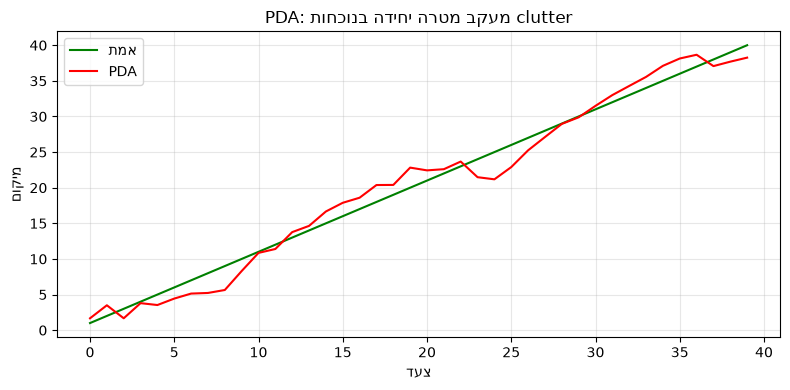

RMSE = 1.73


In [3]:
def pda_update(x, P, F, H, Q, R, zs, PD=0.9, PG=0.99, lam=2e-4):
    x=F@x; P=F@P@F.T+Q                       # predict
    zhat=H@x; S=H@P@H.T+R; K=P@H.T@np.linalg.inv(S)
    if len(zs)==0:
        return x, P, None
    ys=[z-zhat for z in zs]
    norm=1.0/np.sqrt(np.linalg.det(2*np.pi*S))
    Ls=np.array([PD/lam*norm*np.exp(-0.5*float(y@np.linalg.inv(S)@y)) for y in ys])
    b0=1-PD*PG; denom=b0+Ls.sum()
    betas=Ls/denom; beta0=b0/denom
    ybar=sum(b*y for b,y in zip(betas,ys))
    x=x+K@ybar
    # spread of innovations term
    spread=sum(b*np.outer(y,y) for b,y in zip(betas,ys))-np.outer(ybar,ybar)
    Pc=(np.eye(len(x))-K@H)@P
    P=beta0*P+(1-beta0)*Pc+K@spread@K.T
    return x, P, betas

# מטרה 1D נעה, מדידות מיקום ב-clutter
T=1.0; F=np.array([[1,T],[0,1.]]); H=np.array([[1.,0]]); Q=np.array([[.05,.1],[.1,.2]]); R=np.array([[4.]])
x=np.array([0.,1.]); P=np.diag([4.,4.]); true=x.copy()
est=[]; tru=[]
for k in range(40):
    true=F@true; tru.append(true[0])
    zs=[np.array([true[0]+2*rng.standard_normal()])]          # מדידה אמיתית
    zs+=[np.array([true[0]+rng.uniform(-15,15)]) for _ in range(rng.poisson(2))]  # clutter
    x,P,_=pda_update(x,P,F,H,Q,R,zs)
    est.append(x[0])
plt.figure(figsize=(8,4))
plt.plot(tru,'g',label='אמת'); plt.plot(est,'r',label='PDA')
plt.title('PDA: מעקב מטרה יחידה בנוכחות clutter'); plt.legend(); plt.grid(alpha=.3)
plt.xlabel('צעד'); plt.ylabel('מיקום'); plt.tight_layout(); plt.show()
print(f'RMSE = {np.sqrt(np.mean((np.array(est)-np.array(tru))**2)):.2f}')

## ד. הרחבות: JPDA ו-MHT
* **JPDA** (Joint PDA) — מרחיב PDA למספר מטרות, ומחשב הסתברויות שיוך משותפות תוך מניעת התנגשויות.
* **MHT** (Multiple Hypothesis Tracking) — שומר **עץ השערות** של שיוכים לאורך זמן ומכריע בדיעבד; 
  עוצמתי בסביבות צפופות אך יקר חישובית (נדרש גיזום/pruning).
* גישות מודרניות (כמו של Meyer): **belief propagation** על גרף פקטורים לשיוך נתונים סקיילבילי.

**הקשר ל-fusion:** שיוך נכון הוא תנאי מקדים לכל מסנן (מחברת 03) — 'שיוך שגוי' הוא מקור השגיאה 
הדומיננטי במעקב רב-מטרתי, חשוב יותר מבחירת המסנן עצמו.

## סיכום
* **Gating** מצמצם מועמדים דרך מרחק מהלנוביס ($\chi^2$).
* **GNN** = בעיית שיבוץ אופטימלית (החלטה קשיחה).
* **PDA/JPDA** = שקלול הסתברותי רך של כל המדידות בשער; חסין יותר ל-clutter.
* **MHT** דוחה הכרעה ושומר השערות מרובות.